In [1]:
!pip install openai -q

In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
OPENAI_API_KEY = user_secrets.get_secret("OPENAI_KEY")

# 1. Text

In [3]:
# Prompt -> openai model -> repsonse

from openai import OpenAI

client = OpenAI(api_key=OPENAI_API_KEY)

response = client.responses.create(
    model="gpt-5.4",
    input="Hello GPT! Tell me about yourself in 3 sentences"
)

print(response.output_text)

I’m ChatGPT, an AI assistant built by OpenAI to help with writing, coding, research, brainstorming, and answering questions.  
I generate responses by predicting useful language based on patterns in the data I was trained on, but I don’t have feelings, consciousness, or personal experiences.  
You can think of me as a fast, flexible tool for conversation and problem-solving.


In [4]:
response = client.responses.create(
    model="gpt-5.4",
    input= "a+2=7, find a"
)

print(response.output_text)

a = 5


In [5]:
response = client.responses.create(
    model="gpt-5.4",
    input=[
        {"role": "user", "content" : "a+2=7, find a"},
        {"role": "system", "content" : "act like a math teacher"}
    ]
)

print(response.output_text)

Solve for \(a\):

\[
a + 2 = 7
\]

Subtract 2 from both sides:

\[
a = 7 - 2
\]

\[
a = 5
\]

So, **\(a = 5\)**.


In [6]:
response

Response(id='resp_038b5f2a741ff8d10069d600ac83c4819cabf3ed0353b2e4f9', created_at=1775632556.0, error=None, incomplete_details=None, instructions=None, metadata={}, model='gpt-5.4-2026-03-05', object='response', output=[ResponseOutputMessage(id='msg_038b5f2a741ff8d10069d600ad1da8819cbe57d47e002d7e1f', content=[ResponseOutputText(annotations=[], text='Solve for \\(a\\):\n\n\\[\na + 2 = 7\n\\]\n\nSubtract 2 from both sides:\n\n\\[\na = 7 - 2\n\\]\n\n\\[\na = 5\n\\]\n\nSo, **\\(a = 5\\)**.', type='output_text', logprobs=[])], role='assistant', status='completed', type='message', phase='final_answer')], parallel_tool_calls=True, temperature=1.0, tool_choice='auto', tools=[], top_p=0.98, background=False, completed_at=1775632558.0, conversation=None, max_output_tokens=None, max_tool_calls=None, previous_response_id=None, prompt=None, prompt_cache_key=None, prompt_cache_retention=None, reasoning=Reasoning(effort='none', generate_summary=None, summary=None), safety_identifier=None, service_ti

# 2. Image

<img src="https://i.pinimg.com/1200x/1d/ac/40/1dac40b04b16bf6f8a3b5eaa938b3c51.jpg" width="400">

In [7]:
response = client.responses.create(
    model="gpt-5.4",
    input=[
        {
            "role": "user", 
            "content" : [
                {
                    "type" : "input_text",
                    "text" : "What's in this image?"
                },
                {
                    "type" : "input_image",
                    "image_url" : "https://i.pinimg.com/1200x/1d/ac/40/1dac40b04b16bf6f8a3b5eaa938b3c51.jpg"
                }
            ]
        }
    ]
)

print(response.output_text)

A fluffy baby penguin is standing on snowy ice, holding a bouquet of pink tulips. In the background, there’s cold ocean water and snow-covered mountains under a cloudy sky.


# 3. AI Personal Assistant

- answers queries
- summarizes emails

In [8]:
class PersonalAssistant:
    def __init__(self):
        print("Hi, I am your AI assistant. How can I help?")

    def ans_query(self, question):
        response = client.responses.create(
            model="gpt-5.4",
            input=[
                {"role": "system", "content": "Act like a helpful personal assistant"},
                {"role": "user", "content": question}
            ],
            temperature=0.7,
            max_output_tokens=512
        )
        
        print(response.output_text.strip())

    def summarize_email(self, email_text):

        prompt = f"Summarize the following email in 2-3 sentences: {email_text}"
        
        response = client.responses.create(
            model="gpt-5.4",
            input=[
                {"role": "system", "content": "Act like an expert email assistant"},
                {"role": "user", "content": prompt}
            ],
            temperature=0.3,
            max_output_tokens=512
        )
        
        print(response.output_text.strip())

In [9]:
class PersonalAssistant:
    def __init__(self, client, model="gpt-5.4"):
        self.client = client
        self.model = model

        print("Hi, I am your AI assistant. How can I help?")

    def _call_llm(self, system_prompt, user_input, temperature=0.7, max_tokens=512):
        
        response = self.client.responses.create(
            model=self.model,
            input=[
                        {"role": "system", "content": system_prompt},
                        {"role": "user", "content": user_input}
                    ],
            temperature=temperature,
            max_output_tokens=max_tokens
        )

        return response.output_text.strip()

    def ans_query(self, question):
        reply = self._call_llm(
            system_prompt="You are a helpful personal assistant.",
            user_input=question
        )

        print(reply)  

    def summarize_email(self, email_text):
        reply = self._call_llm(
            system_prompt="You are an expert email assistant.",
            user_input=f"Summarize this email in 2-3 sentences:\n{email_text}",
            temperature=0.3
        )

        print(reply)

In [10]:
assistant = PersonalAssistant(client)

Hi, I am your AI assistant. How can I help?


In [11]:
assistant.ans_query("what is your name?")

I’m your AI assistant. You can call me ChatGPT if you’d like.


In [12]:
# sample email 

sample_email1 =  """Subject: Update on Semester Project and Presentation Prep

Hi Team,

I hope you’re all doing well.

I wanted to sync up on our progress for the Phishing Detection System. I’ve finished the initial training of the model using the dataset we discussed, but the accuracy is currently hovering around 82%. I think we need to perform some additional feature engineering on the URL structures to improve this.

Siddharth, could you take a look at the preprocessing script? I think there’s a bug in how it handles special characters. Ananya, have you started on the PowerPoint slides for our presentation next Tuesday? We need the architectural diagram finished by Sunday so I can include the model metrics.

Also, Professor Mehta moved our review slot. We are now scheduled for Monday at 2:30 PM in Lab 204, instead of Tuesday morning. Please confirm if you can make it.

Lastly, don't forget to upload your individual code modules to the GitHub repo by tomorrow night.

Best,

Radhika"""

assistant.summarize_email(sample_email1)



Radhika shared that the Phishing Detection System model has completed initial training, but its accuracy is only about 82%, so more feature engineering on URL structures is needed. She asked Siddharth to check a preprocessing bug with special characters, reminded Ananya to finish the presentation slides and architectural diagram by Sunday, and noted that the project review has been moved to Monday at 2:30 PM in Lab 204.

She also asked everyone to confirm their availability for the new review time and to upload their individual code modules to the GitHub repo by tomorrow night.


# 4. Image Generation

## 4.1 Responses API

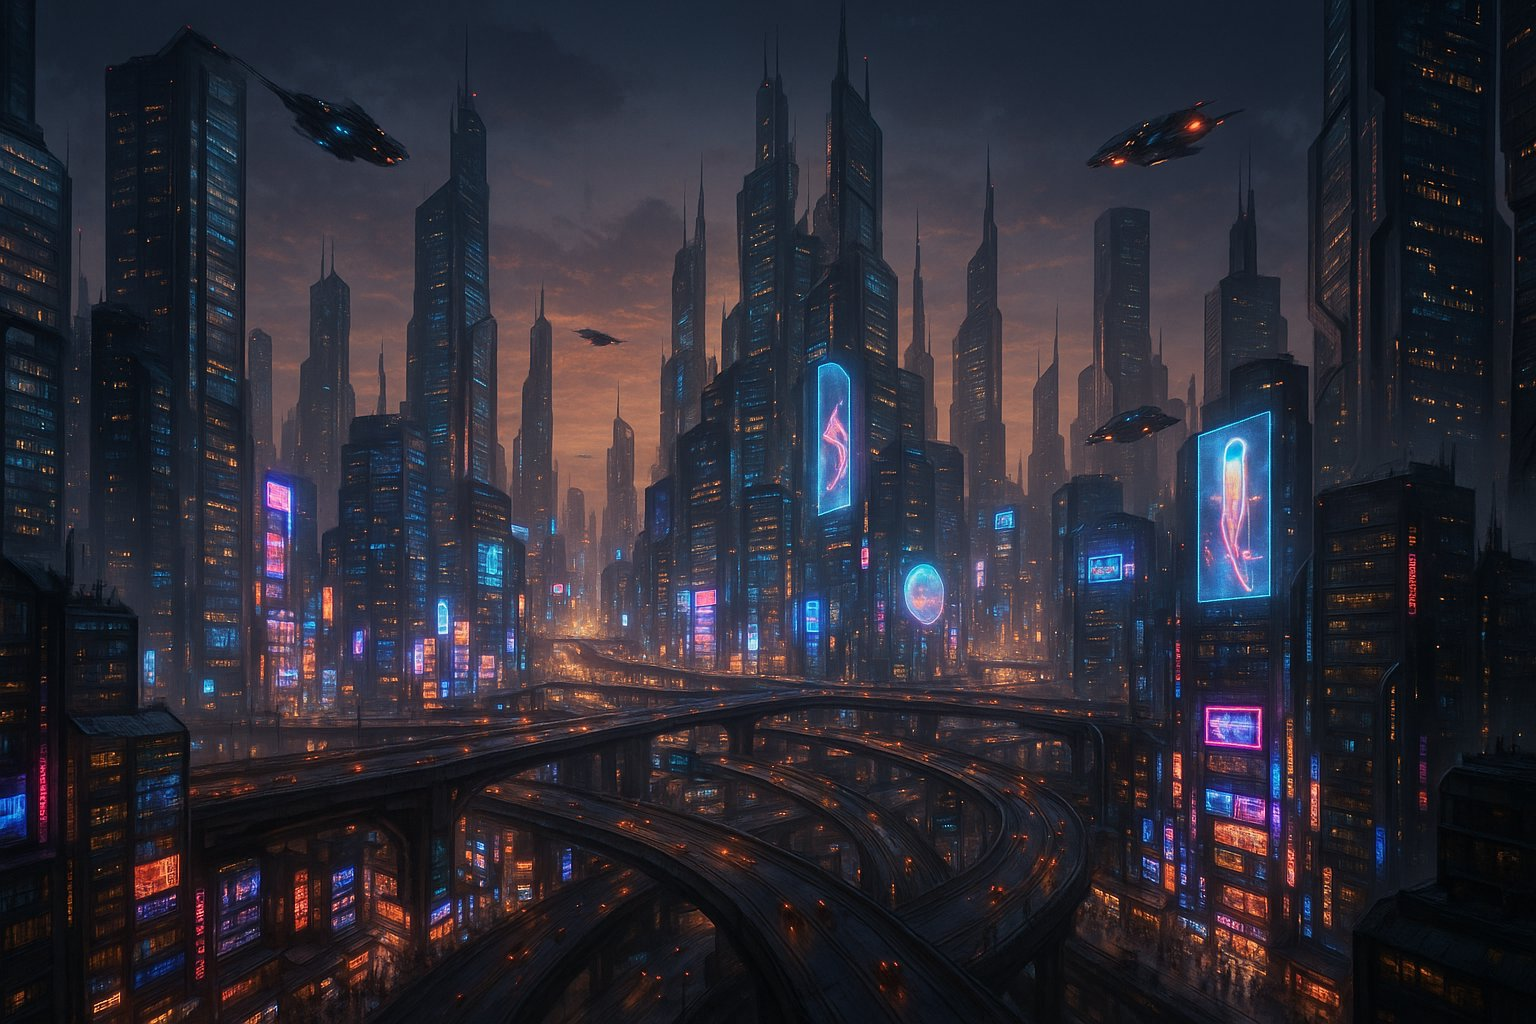

In [13]:
import base64
import os
from IPython.display import Image as DisplayImage, display 
from PIL import Image as PILImage 

# 1. API Call
response = client.responses.create(
    model="gpt-5.4",
    input="Generate an image of a highly detailed futuristic city",
    tools=[{"type": "image_generation"}]
)

# 2. Extract the base64 string
image_data = [
    output.result
    for output in response.output
    if output.type == "image_generation_call"
]

# 3. Decode and Save Temporary PNG
if image_data:
    image_base64 = image_data[0]
    with open("temp.png", "wb") as f:
        f.write(base64.b64decode(image_base64))

    # 4. Compress & Convert
    img = PILImage.open("temp.png")
    img = img.convert("RGB")
    img.save("image1.jpg", "JPEG", quality=85, optimize=True)

    # 5. Clean up the heavy file
    os.remove("temp.png")

    # 6. Display the light version
    display(DisplayImage(filename='image1.jpg'))


## 4.2 Image Generation API

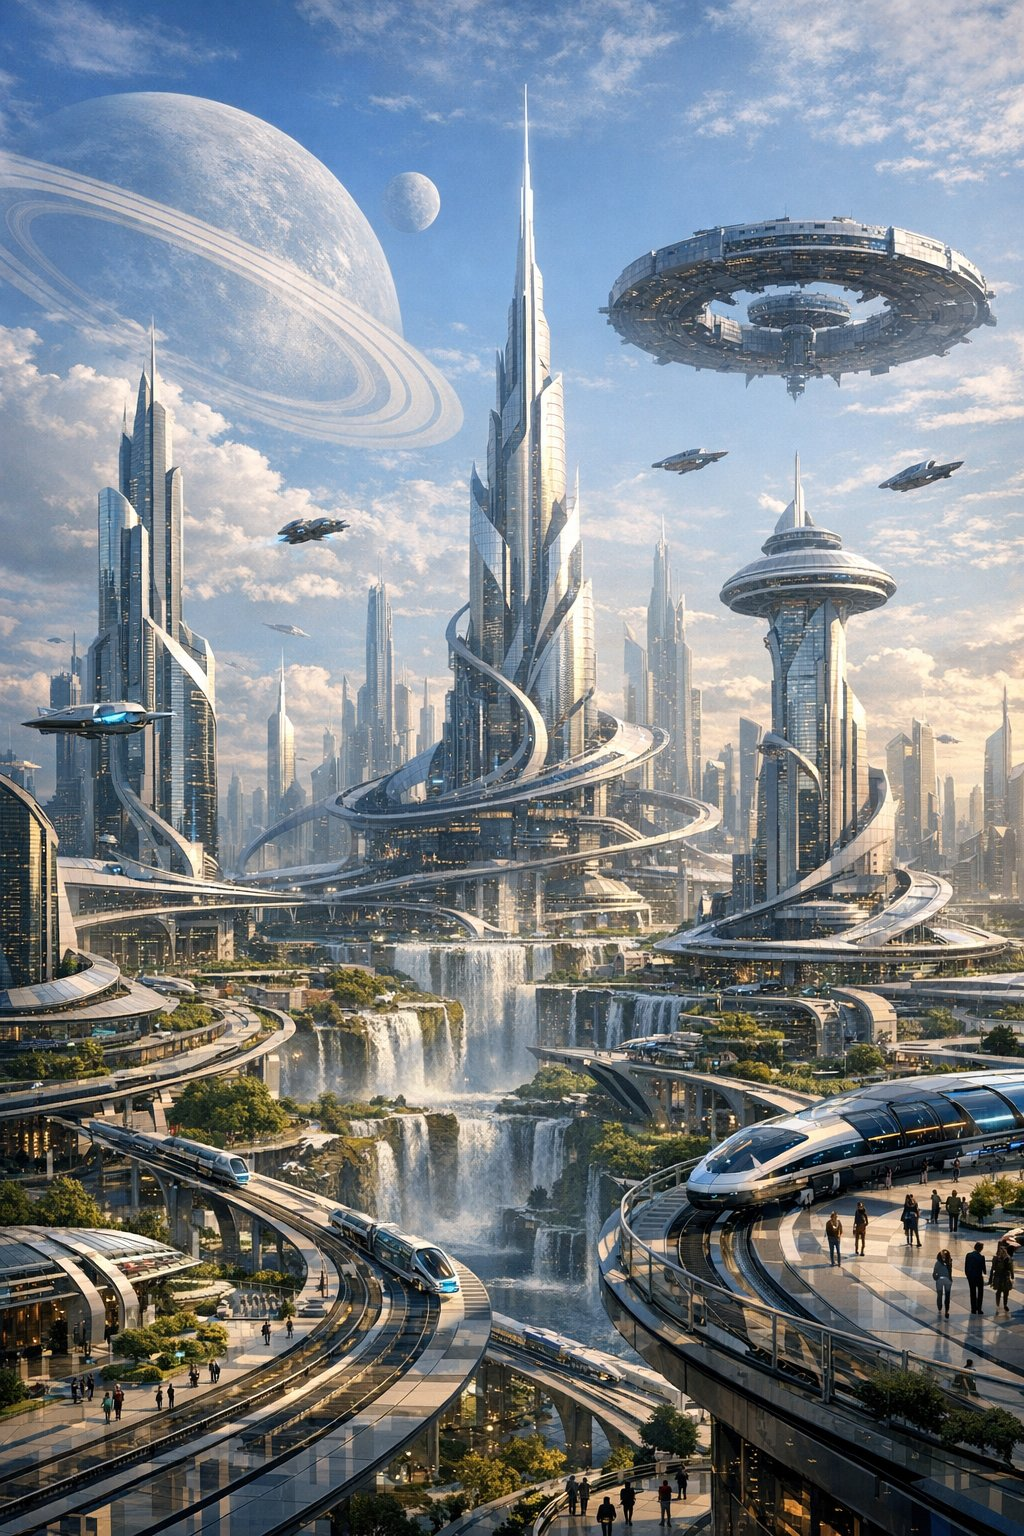

In [14]:
prompt = "Generate an image of a highly detailed futuristic city."

result = client.images.generate(
    model="gpt-image-1.5",
    prompt=prompt
)

image_base64 = result.data[0].b64_json
image_bytes = base64.b64decode(image_base64)

with open("temp.png", "wb") as f:
    f.write(image_bytes)

img = PILImage.open("temp.png")
img.convert("RGB").save("image2.jpg", "JPEG", quality=85, optimize=True)
os.remove("temp.png")

display(DisplayImage(filename='image2.jpg', width=500))

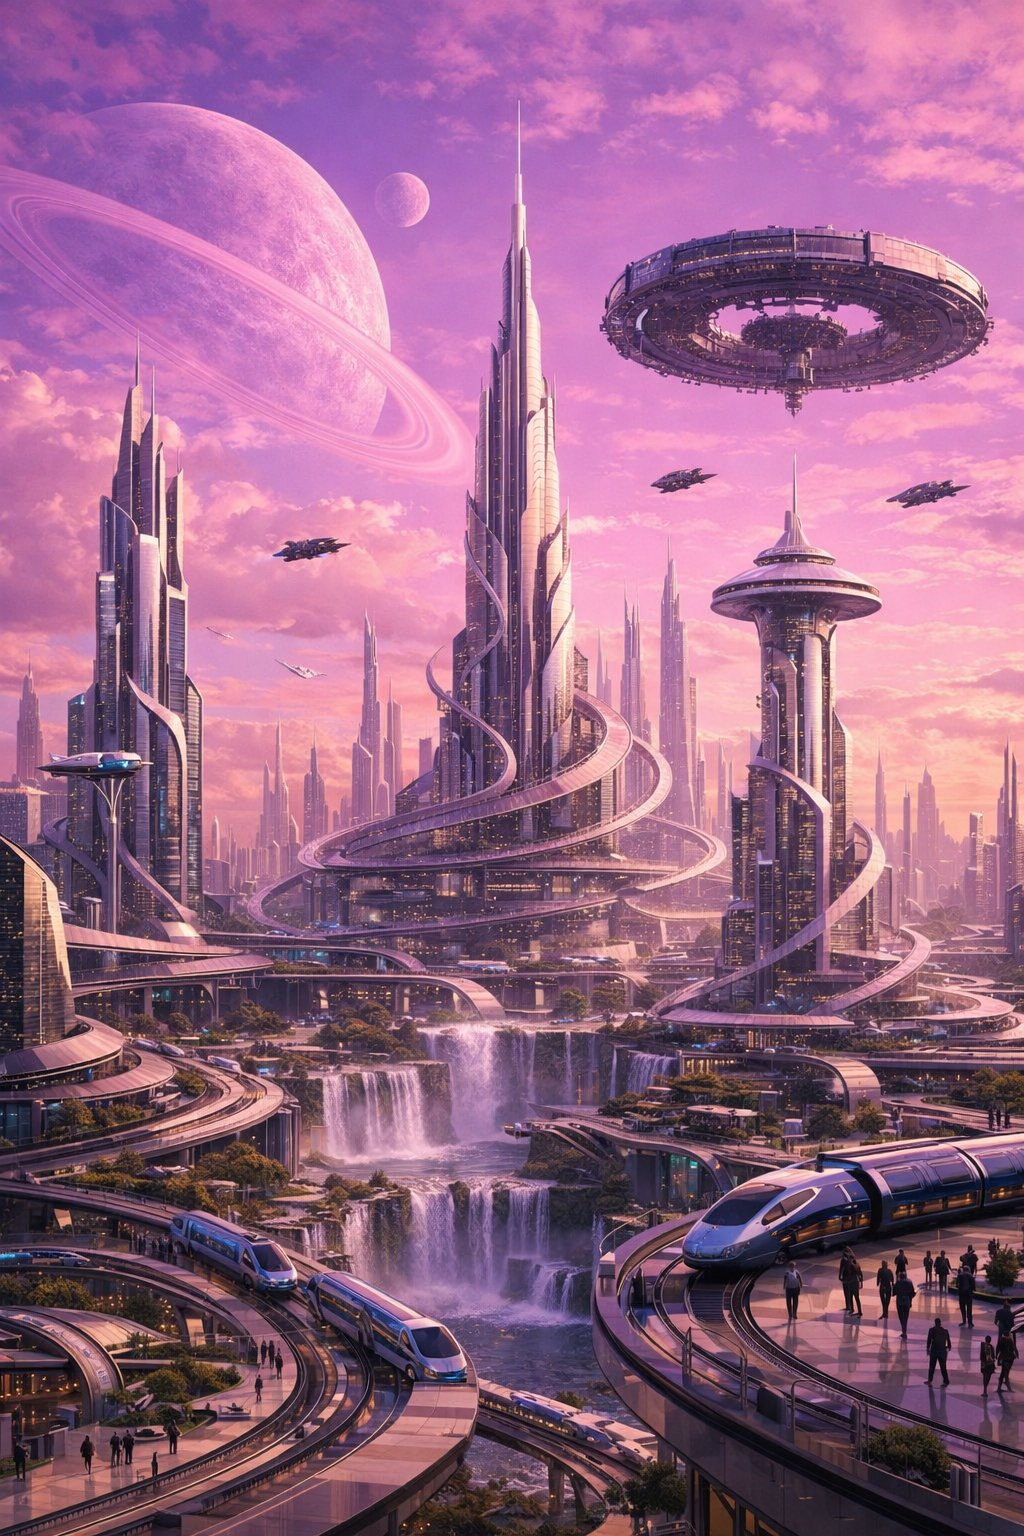

In [15]:
# EDIT

prompt = "Take the reference image and make the sky pinkish-purple."

result = client.images.edit(
    model="gpt-image-1.5",
    prompt=prompt,
    image = [
        open("image2.jpg", "rb"),
    ]
)

image_base64 = result.data[0].b64_json
image_bytes = base64.b64decode(image_base64)

with open("temp.png", "wb") as f:
    f.write(image_bytes)

img = PILImage.open("temp.png")
img.convert("RGB").save("image3.jpg", "JPEG", quality=85, optimize=True)
os.remove("temp.png")

display(DisplayImage(filename='image3.jpg', width=500))